# HGQ Test
This notebook is a test for the HGQ2 Framework v0.1.6. After some studies, the framework did not seem to output the expected quantized values. We implemented our own implementation and we are testing it against the framework. In the end, it is shown that the wasserstein distances and the model output indeed does not match.

In [1]:
from hgq.layers import QDense
from hgq.config import QuantizerConfig, QuantizerConfigScope
from keras.layers import Dense
from keras import Sequential
import numpy as np
from scipy.stats import wasserstein_distance
import polars as pl
from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()
from neuralnet.quantization.hgq import hgq_quantize
from neuralnet.quantization.keras import fixed_point_quantize
from neuralnet.plotting import plot_variable_distribution_comparison

2026-07-16 20:14:17.977241: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-16 20:14:17.977594: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-16 20:14:18.020528: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-16 20:14:19.028511: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

# Defining the models

In [2]:
fp_model  = Sequential([
    Dense(5, input_shape=(50,), activation='relu', use_bias=False),
    Dense(1, activation='sigmoid', use_bias=False)
])
fp_model.summary()

/home/lucasbanunes/miniconda3/envs/neuralnet/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-16 20:14:20.798452: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255 (1020.00 B)

 Trainable params: 255 (1020.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
weights_quantizer_config = QuantizerConfig(
    q_type="kif",
    place='weight',
    k0=True,
    i0=7,
    f0=15,
    overflow_mode='SAT',
    qnoise_factor=0.0
)
bias_quantizer_config = QuantizerConfig(
    q_type="kif",
    place='bias',
    k0=True,
    i0=7,
    f0=15,
    overflow_mode='SAT',
    qnoise_factor=0.0
)
hgq_ptq_model = hgq_quantize(
    fp_model,
    weights_quantizer_config,
    bias_quantizer_config,
    name='sequential_hgq_quantization'
)
hgq_ptq_model.summary()

Model: "sequential_hgq_quantization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ q_dense (QDense)                │ (None, 5)              │         1,153 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_dense_1 (QDense)              │ (None, 1)              │            38 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,191 (3.74 KB)

 Trainable params: 820 (3.20 KB)

 Non-trainable params: 371 (554.00 B)

In [4]:
custom_ptq_model = fixed_point_quantize(
    fp_model,
    floating_bits=15,
    integer_bits=7,
    name='sequential_custom_quantization'
)
custom_ptq_model.summary()

Model: "sequential_custom_quantization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ quantized_dense                 │ (None, 5)              │           257 │
│ (FixedPointQuantizationDense)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quantized_dense_1               │ (None, 1)              │             8 │
│ (FixedPointQuantizationDense)   │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265 (1.04 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 4 (16.00 B)

# Plotting outputs

In [5]:
input_data = np.random.rand(1000000, 50).astype(np.float32)
fp_output = fp_model.predict(input_data, batch_size=int(2**15))
hgq_ptq_output = hgq_ptq_model.predict(input_data, batch_size=int(2**15))
custom_ptq_output = custom_ptq_model.predict(input_data, batch_size=int(2**15))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [6]:
analysis_df = pl.DataFrame({'fp.output': fp_output.flatten(), 'hgq_ptq.output': hgq_ptq_output.flatten(), 'custom_ptq.output': custom_ptq_output.flatten()})
analysis_df

fp.output,hgq_ptq.output,custom_ptq.output
f32,f32,f32
0.547111,0.5549,0.547109
0.582521,0.588677,0.582513
0.618481,0.626389,0.618478
0.566406,0.562573,0.566408
0.530903,0.509465,0.530905
…,…,…
0.606825,0.610103,0.606819
0.476391,0.498362,0.476382
0.507702,0.518925,0.507697


/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:228: RuntimeWarning: divide by zero encountered in divide
  rel_diff = ((heights - ref_heights) / ref_heights) * 100
/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:228: RuntimeWarning: invalid value encountered in divide
  rel_diff = ((heights - ref_heights) / ref_heights) * 100
/home/lucasbanunes/miniconda3/envs/neuralnet/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


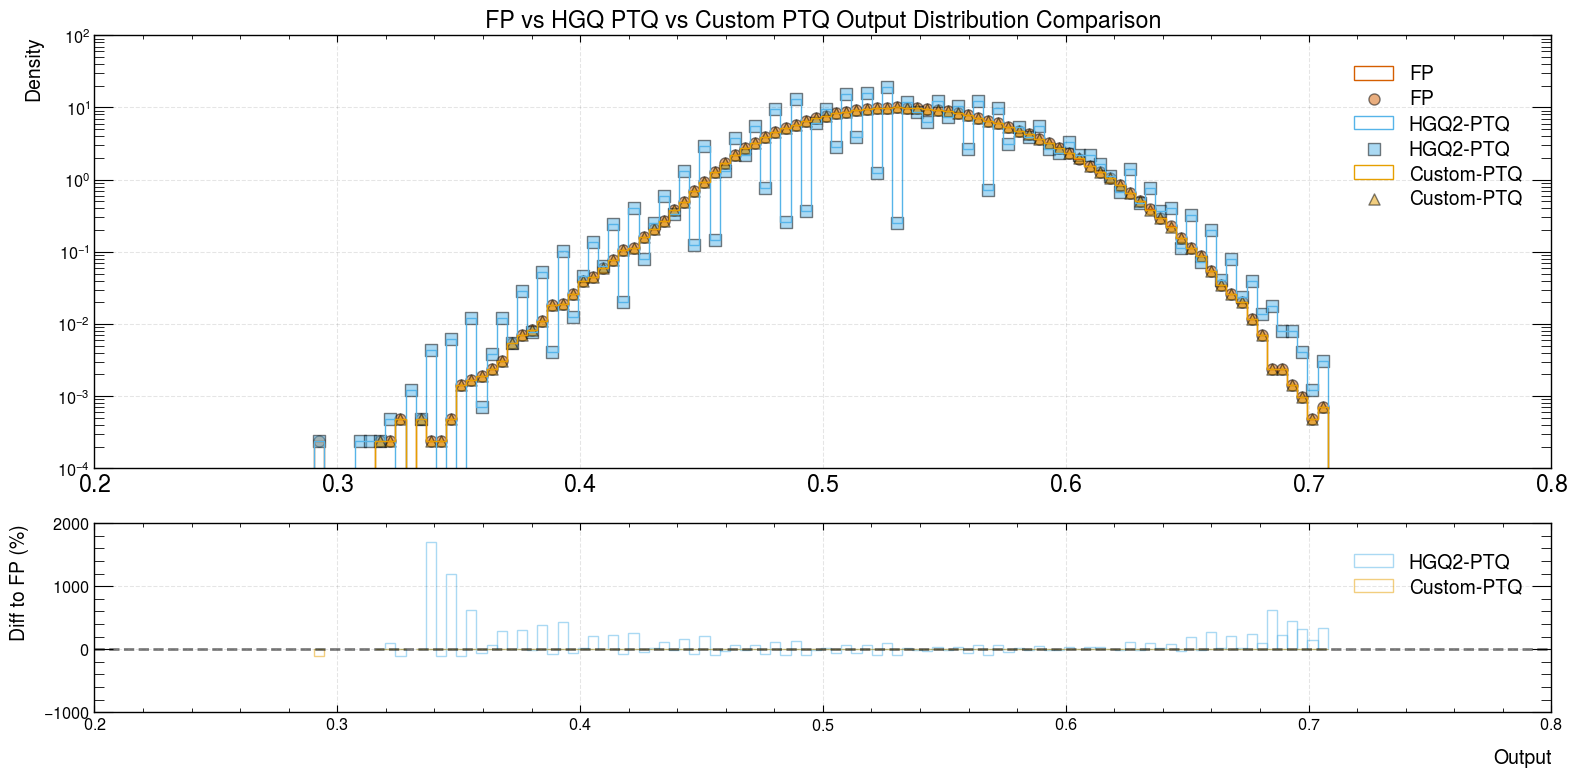

In [7]:
fig, _, bottom_ax = plot_variable_distribution_comparison(
    variable_label='Output',
    ref={'name': 'fp.output', 'label': 'FP', 'color': 'C0', 'marker': 'o'},
    to_compare=[
        {'name': 'hgq_ptq.output', 'label': 'HGQ2-PTQ', 'color': 'C1', 'marker': 's'},
        {'name': 'custom_ptq.output', 'label': 'Custom-PTQ', 'color': 'C2', 'marker': '^'},
    ],
    data=analysis_df,
    title='FP vs HGQ PTQ vs Custom PTQ Output Distribution Comparison',
    scale='log',
    hist_kwargs=dict(bins=100),
    scatter=True,
    fig_kwargs=dict(figsize=(16, 8))
)
# wass_distance = wasserstein_distance(fp_output.flatten(), ptq_output.flatten())
# bottom_ax.plot([], [], ' ', label=f"Wasserstein Distance: {wass_distance:.4f}")
# bottom_ax.legend()
fig.tight_layout()

# Wasserstein distance plots

In [14]:
def wasserstein_distances_per_bits(input_data, fp_output, quantized_model_generator, n_bits):
    # ptq_output = custom_ptq_output
    distances = []
    first_quartile_distances = []
    last_quartile_distances = []
    first_tenth_percentile_distances = []
    last_tenth_percentile_distances = []
    fp_first_quartile_limit, fp_third_quartile_limit, fp_tenth_percentile_limit, fp_ninetieth_percentile_limit = \
        np.quantile(fp_output.flatten(), [0.25, 0.75, 0.1, 0.9])
    fp_output.flatten()
    fp_first_quartile = fp_output[fp_output <= fp_first_quartile_limit]
    fp_third_quartile = fp_output[fp_output >= fp_third_quartile_limit]
    fp_tenth_percentile = fp_output[fp_output <= fp_tenth_percentile_limit]
    fp_ninetieth_percentile = fp_output[fp_output >= fp_ninetieth_percentile_limit]
    for i, bits in enumerate(n_bits):
        print(f"{i} - Bits: {bits}")
        ptq_model = quantized_model_generator(bits)
        ptq_output = ptq_model.predict(input_data, batch_size=int(2**15)).flatten()
        wass_distance = wasserstein_distance(fp_output.flatten(), ptq_output.flatten())
        distances.append(wass_distance)
        ptq_first_quartile_limit, ptq_third_quartile_limit, ptq_tenth_percentile_limit, ptq_ninetieth_percentile_limit = \
            np.quantile(ptq_output.flatten(), [0.25, 0.75, 0.1, 0.9])
        ptq_first_quartile = ptq_output[ptq_output <= ptq_first_quartile_limit]
        first_quartile_distance = wasserstein_distance(fp_first_quartile, ptq_first_quartile)
        first_quartile_distances.append(first_quartile_distance)
        ptq_third_quartile = ptq_output[ptq_output >= ptq_third_quartile_limit]
        last_quartile_distance = wasserstein_distance(fp_third_quartile, ptq_third_quartile)
        last_quartile_distances.append(last_quartile_distance)
        ptq_tenth_percentile = ptq_output[ptq_output <= ptq_tenth_percentile_limit]
        first_tenth_percentile_distance = wasserstein_distance(fp_tenth_percentile, ptq_tenth_percentile)
        first_tenth_percentile_distances.append(first_tenth_percentile_distance)
        ptq_ninetieth_percentile = ptq_output[ptq_output >= ptq_ninetieth_percentile_limit]
        last_tenth_percentile_distance = wasserstein_distance(fp_ninetieth_percentile, ptq_ninetieth_percentile)
        last_tenth_percentile_distances.append(last_tenth_percentile_distance)
        print(f"{i} - Wasserstein Distance: {wass_distance:.4f}")
        print(f"{i} - First Quartile Wasserstein Distance: {first_quartile_distance:.4f}")
        print(f"{i} - Last Quartile Wasserstein Distance: {last_quartile_distance:.4f}")
        print(f"{i} - First Tenth Percentile Wasserstein Distance: {first_tenth_percentile_distance:.4f}")
        print(f"{i} - Last Tenth Percentile Wasserstein Distance: {last_tenth_percentile_distance:.4f}")
    
    result = {
        'distances': {
            'distances': distances,
            'bits': n_bits,
            'label': 'Total'
        },
        'first_quartile_distances': {
            'distances': first_quartile_distances,
            'bits': n_bits,
            'label': 'First Quartile'
        },
        'last_quartile_distances': {
            'distances': last_quartile_distances,
            'bits': n_bits,
            'label': 'Last Quartile'
        },
        'first_tenth_percentile_distances': {
            'distances': first_tenth_percentile_distances,
            'bits': n_bits,
            'label': 'First Tenth Percentile'
        },
        'last_tenth_percentile_distances': {
            'distances': last_tenth_percentile_distances,
            'bits': n_bits,
            'label': 'Last Tenth Percentile'
        }
    }

    return result

In [15]:
def custom_ptq_model_generator(bits):
    return fixed_point_quantize(
        fp_model,
        floating_bits=bits,
        integer_bits=bits
    )

In [16]:
def hgq_ptq_model_generator(bits):
    return hgq_quantize(
        fp_model,
        QuantizerConfig(
            q_type="kif",
            place='weight',
            k0=True,
            i0=bits,
            f0=bits,
        ),
        QuantizerConfig(
            q_type="kif",
            place='bias',
            k0=True,
            i0=bits,
            f0=bits,
        )
    )   

In [ ]:
custom_ptq_distances = wasserstein_distances_per_bits(input_data, fp_output, custom_ptq_model_generator, n_bits=np.arange(1, 33))

0 - Bits: 1
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
0 - Wasserstein Distance: 0.1328
0 - First Quartile Wasserstein Distance: 0.0818
0 - Last Quartile Wasserstein Distance: 0.1484
0 - First Tenth Percentile Wasserstein Distance: 0.0328
0 - Last Tenth Percentile Wasserstein Distance: 0.1289
1 - Bits: 2
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1 - Wasserstein Distance: 0.0174
1 - First Quartile Wasserstein Distance: 0.0135
1 - Last Quartile Wasserstein Distance: 0.0132
1 - First Tenth Percentile Wasserstein Distance: 0.0268
1 - Last Tenth Percentile Wasserstein Distance: 0.0225
2 - Bits: 3
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
2 - Wasserstein Distance: 0.0168
2 - First Quartile Wasserstein Distance: 0.0105
2 - Last Quartile Wasserstein Distance: 0.0392
2 - First Tenth Percentile Wasserstein Distance: 0.0087
2 - Last Tenth Percentile Wasserstein Distance: 0.0366


In [18]:
def make_wasserstein_distance_plot(distances_dict, title="Wasserstein Distance vs Number of Bits"):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(12, 6))
    for key, distance_info in distances_dict.items():
        # auc = np.trapz(distance_info["distances"], distance_info['bits'])
        ax.plot(distance_info['bits'], distance_info["distances"], label=distance_info["label"], marker='o')
    ax.grid(linestyle="--", alpha=0.1, color="k")
    ax.set_xlabel("Number of Bits")
    ax.set_ylabel("Wasserstein Distance")
    ax.set_title(title)
    ax.legend()
    return fig, ax

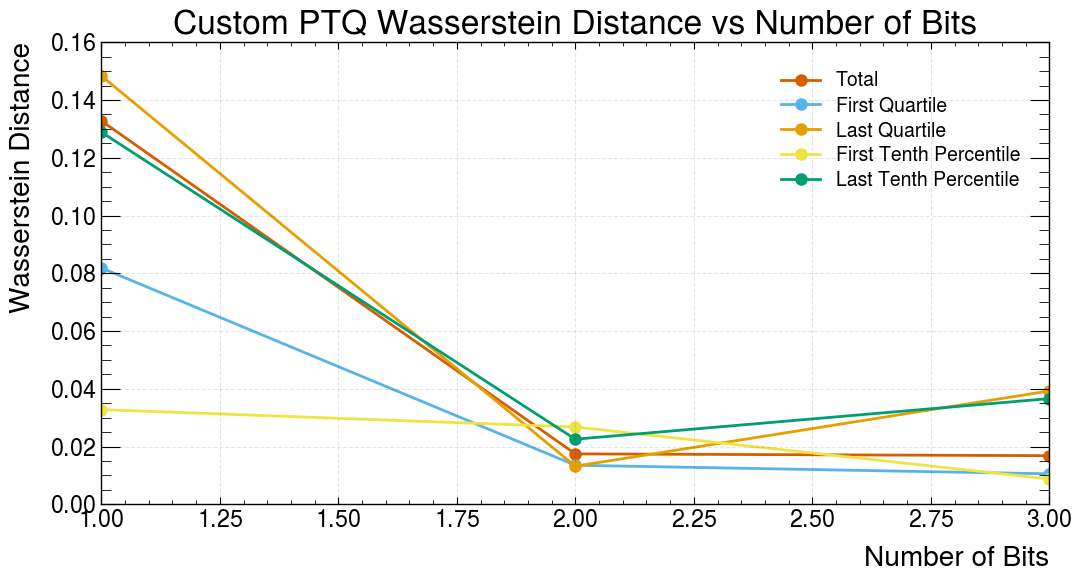

In [19]:
fig, ax = make_wasserstein_distance_plot(
    custom_ptq_distances,
    title="Custom PTQ Wasserstein Distance vs Number of Bits"
)

In [ ]:
hgq_ptq_distances = wasserstein_distances_per_bits(input_data, fp_output, hgq_ptq_model_generator, n_bits=np.arange(1, 33))

0 - Bits: 1
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
0 - Wasserstein Distance: 0.1443
0 - First Quartile Wasserstein Distance: 0.0855
0 - Last Quartile Wasserstein Distance: 0.1866
0 - First Tenth Percentile Wasserstein Distance: 0.0570
0 - Last Tenth Percentile Wasserstein Distance: 0.2152
1 - Bits: 2
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
1 - Wasserstein Distance: 0.0103
1 - First Quartile Wasserstein Distance: 0.0128
1 - Last Quartile Wasserstein Distance: 0.0050
1 - First Tenth Percentile Wasserstein Distance: 0.0214
1 - Last Tenth Percentile Wasserstein Distance: 0.0060
2 - Bits: 3
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
2 - Wasserstein Distance: 0.0136
2 - First Quartile Wasserstein Distance: 0.0033
2 - Last Quartile Wasserstein Distance: 0.0266
2 - First Tenth Percentile Wasserstein Distance: 0.0073
2 - Last Tenth Percentile Wasserstein Distance: 0.0278


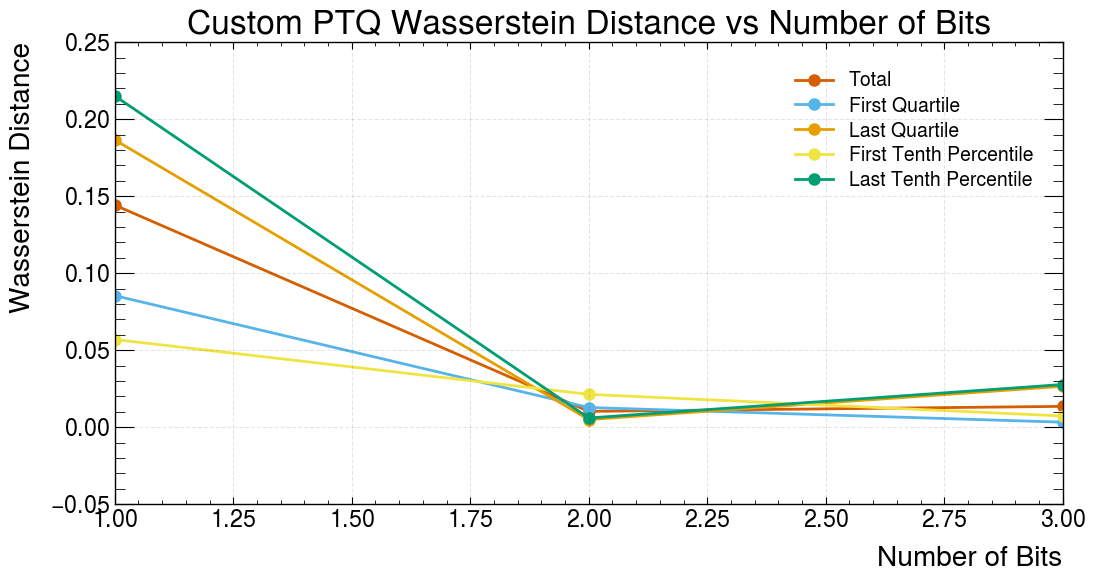

In [21]:
fig, ax = make_wasserstein_distance_plot(
    hgq_ptq_distances,
    title="Custom PTQ Wasserstein Distance vs Number of Bits"
)